In [1]:
import importlib
import matplotlib.pyplot as plt
import pandas as pd
import sys

# performance imports for torch: torch kernel uses one core only.
import os
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"
os.environ["TORCH_NUM_THREADS"] = "1" 

import torch

sys.path.insert(0, '..')
sys.path.insert(0, '../..')
sys.path.insert(0, '../../..')
sys.path.insert(0, '../../../..')
sys.path.insert(0, '../../../../..')

# Decoding
import suffix_pred.evalaution.decode_test_set_suffixes
importlib.reload(suffix_pred.evalaution.decode_test_set_suffixes)
from suffix_pred.evalaution.decode_test_set_suffixes import TestSetSuffixDecoder, DecodingConfig

# Evaluation metrics
import suffix_pred.evalaution.evalaution_metrics
importlib.reload(suffix_pred.evalaution.evalaution_metrics)
from suffix_pred.evalaution.evalaution_metrics import (evaluate_dls, dls_per_prefix_length, average_dls, load_decoded_suffixes)

# Model
import suffix_pred.models.K_UED_LSTM
importlib.reload(suffix_pred.models.K_UED_LSTM)
from suffix_pred.models.K_UED_LSTM import DropoutUncertaintyEncoderDecoderLSTM

In [2]:
# Model
file_path_model = '../../../../../../models/Procurement/clean/Procurement_UED_LSTM_v1_clean.pkl'
model = DropoutUncertaintyEncoderDecoderLSTM.load(file_path_model, dropout=0.1)

# Load the data
# Path to your pickle file (saved with torch.save)
file_path_test = '../../../../../../data/Procurement/tensor_data/normal/procurement_all_5_test.pkl'
# Load the dataset using torch.load
test_dataset = torch.load(file_path_test, weights_only=False)

Dynamic data set categories:  ([('concept:name', 18, {'Approve Invoice': 1, 'Approve Requisition': 2, 'Close Case': 3, 'Collect Quotations': 4, 'Create Purchase Order': 5, 'Create Purchase Requisition': 6, 'EOS': 7, 'Evaluate Quotations': 8, 'Flag Invoice Mismatch': 9, 'Pay Invoice': 10, 'Receive Goods': 11, 'Reject Requisition': 12, 'Reorder Goods': 13, 'Request Credit Note': 14, 'Revise Requisition': 15, 'Select Supplier': 16, 'Send Purchase Order': 17}), ('org:resource', 22, {'Alice': 1, 'Bob': 2, 'Buyer_1': 3, 'Buyer_2': 4, 'Buyer_3': 5, 'Carol': 6, 'Clerk_1': 7, 'Clerk_2': 8, 'Clerk_3': 9, 'David': 10, 'EOS': 11, 'Eva': 12, 'Frank': 13, 'Manager_FIN_1': 14, 'Manager_FIN_2': 15, 'Manager_IT_1': 16, 'Manager_IT_2': 17, 'Manager_OPS_1': 18, 'Manager_OPS_2': 19, 'Receiver_A': 20, 'Receiver_B': 21}), ('budget_status', 4, {'EOS': 1, 'approved': 2, 'pending': 3}), ('supplier_type', 6, {'EOS': 1, 'preferred': 2, 'risky': 3, 'standard': 4, nan: 5}), ('goods_match', 5, {'EOS': 1, 'False': 2

In [3]:
# Step 1: Decode suffixes (probabilistic)
config = DecodingConfig(concept_name="concept:name",
                        eos_value="EOS",
                        probabilistic_samples=100,
                        num_processes=32)

decoder = TestSetSuffixDecoder(model=model, dataset=test_dataset, config=config)

mode = "probabilistic"
outputs = decoder.decode(mode=mode,
                         random_order=False,
                         cache_path='../../../../../../eval_results/Procurement/clean/procurement_ued_lstm_clean_outputs.pkl',
                         reuse_cache=False,
                         parallel_inference=True,
                         num_processes=32)

print(f"Decoded {len(outputs)} prefix rows in '{mode}' mode")

# --- Step 2: Evaluate DLS from decoded outputs ---
prob_df = evaluate_dls(outputs, probabilistic_reduction="mean")
prob_per_prefix = dls_per_prefix_length(prob_df)

prob_avg = average_dls(prob_df)
prob_min = float(prob_df["dls_min"].mean())
prob_max = float(prob_df["dls_max"].mean())

print(f"Average DLS ({mode}, mean over T samples): {prob_avg:.4f}")
print(f"Average DLS min ({mode}): {prob_min:.4f}")
print(f"Average DLS max ({mode}): {prob_max:.4f}")

Probabilistic inference chunks:   0%|          | 0/32 [00:00<?, ?it/s]

Decoded 23584 prefix rows in 'probabilistic' mode


Average DLS (probabilistic, mean over T samples): 0.8527
Average DLS min (probabilistic): 0.5018
Average DLS max (probabilistic): 0.9870


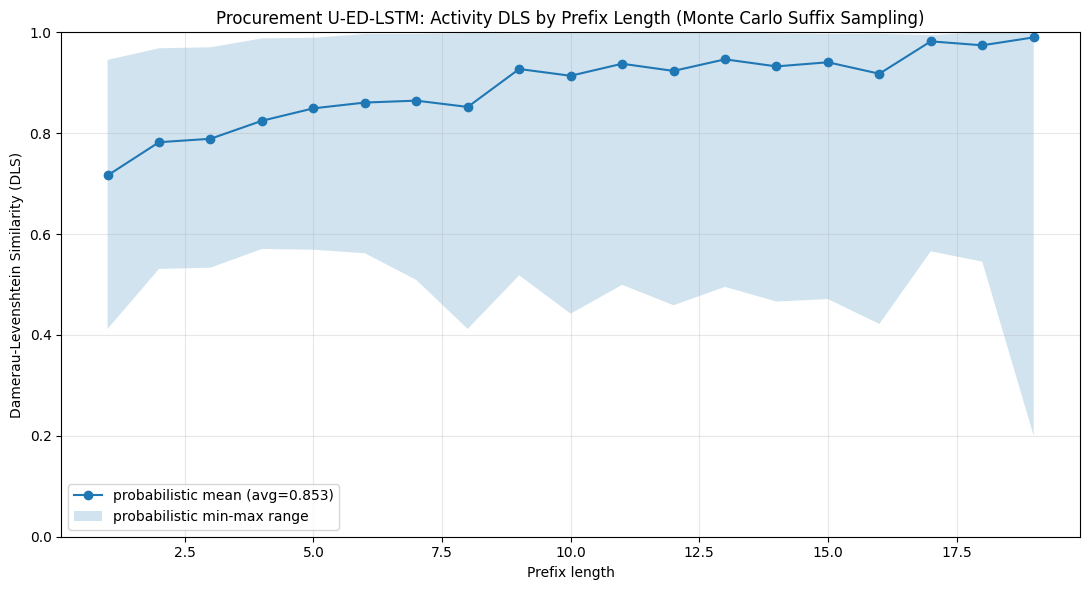

,mode,average_dls,average_dls_min,average_dls_max
0,probabilistic,0.852703,0.501841,0.987015


In [4]:
# One combined plot (single method requested: probabilistic only)
plt.figure(figsize=(11, 6))

plt.plot(prob_per_prefix["prefix_len"],
         prob_per_prefix["dls"],
         marker="o",
         label=f"probabilistic mean (avg={prob_avg:.3f})")

# Plot min/max range band for probabilistic decoding if available
if {"dls_min", "dls_max"}.issubset(prob_per_prefix.columns):
    plt.fill_between(prob_per_prefix["prefix_len"],
                     prob_per_prefix["dls_min"],
                     prob_per_prefix["dls_max"],
                     alpha=0.2,
                     label="probabilistic min-max range")

plt.title("Procurement U-ED-LSTM: Activity DLS by Prefix Length (Monte Carlo Suffix Sampling)")
plt.xlabel("Prefix length")
plt.ylabel("Damerau-Levenshtein Similarity (DLS)")
plt.ylim(0.0, 1.0)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# Optional summary table
summary = pd.DataFrame({
    "mode": [mode],
    "average_dls": [prob_avg],
    "average_dls_min": [prob_min],
    "average_dls_max": [prob_max],
}).sort_values("average_dls", ascending=False).reset_index(drop=True)
summary

In [5]:
# Load decoded outputs from pickle and inspect 5 example prefixes
cached_outputs = load_decoded_suffixes('../../../../../../eval_results/Procurement/clean/procurement_ued_lstm_clean_outputs.pkl')

for row in cached_outputs[:5]:
    print(f"Case: {row['case_id']}  |  Prefix len: {row['prefix_len']}")
    print(f"  Prefix:         {row['prefix']}")
    print(f"  Target suffix:  {row['target_suffix']}")
    print(f"  Sampled suffixes ({len(row['decoded_suffixes'])}):")
    for i, s in enumerate(row["decoded_suffixes"][:5]):
        print(f"    [{i}] {s}")
    if len(row["decoded_suffixes"]) > 5:
        print(f"    ... and {len(row['decoded_suffixes']) - 5} more")
    print()

Case: C09787  |  Prefix len: 1
  Prefix:         ['Create Purchase Requisition']
  Target suffix:  ['Reject Requisition', 'Revise Requisition', 'Approve Requisition', 'Collect Quotations', 'Evaluate Quotations', 'Select Supplier', 'Create Purchase Order', 'Send Purchase Order', 'Receive Goods', 'Flag Invoice Mismatch', 'Request Credit Note', 'Reorder Goods', 'Close Case']
  Sampled suffixes (100):
    [0] ['Reject Requisition', 'Revise Requisition', 'Approve Requisition', 'Revise Requisition', 'Reject Requisition', 'Select Supplier', 'Evaluate Quotations', 'Revise Requisition', 'Approve Requisition', 'Collect Quotations', 'Evaluate Quotations', 'Collect Quotations', 'Create Purchase Order', 'Send Purchase Order', 'Receive Goods', 'Approve Invoice', 'Request Credit Note', 'Close Case']
    [1] ['Reject Requisition', 'Revise Requisition', 'Reject Requisition', 'Revise Requisition', 'Reject Requisition', 'Revise Requisition', 'Approve Requisition', 'Select Supplier', 'Create Purchase Orde